## Imports

Bibliothèques pour SARIMAX, diagnostics et validation.

In [1]:
import os
os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
import time
import warnings
warnings.filterwarnings('ignore')

## Chargement et split des données

Charger master_dataset.csv et diviser en train (jusqu'à 2021-12) et test (après).

In [2]:
df = pd.read_csv('data/processed/master_dataset.csv', parse_dates=['date'], index_col='date')

TRAIN_END = '2021-12-01'

ipc_train = df.loc[:TRAIN_END, 'ipc'].dropna()
ipc_test = df.loc[TRAIN_END:, 'ipc'].dropna()
besi_train = df.loc[:TRAIN_END, 'besi'].fillna(0)
besi_test = df.loc[TRAIN_END:, 'besi'].fillna(0)

print(f"Train: {len(ipc_train)} obs (jusqu'à {ipc_train.index[-1]})")
print(f"Test: {len(ipc_test)} obs (de {ipc_test.index[0]} à {ipc_test.index[-1]})")
print(f"BESI train shape: {besi_train.shape}")
print(f"BESI test shape: {besi_test.shape}")

Train: 144 obs (jusqu'à 2021-12-01 00:00:00)
Test: 37 obs (de 2021-12-01 00:00:00 à 2024-12-01 00:00:00)
BESI train shape: (144,)
BESI test shape: (37,)


## Grille AIC : Sélection des ordres SARIMA

Tester 6 combinaisons SARIMA et sélectionner le meilleur modèle par AIC.

In [3]:
# Grille de combinaisons à tester
grid = [
    ((2, 1, 1), (0, 1, 1, 12), '(2,1,1)(0,1,1)[12]'),
    ((1, 1, 1), (0, 1, 1, 12), '(1,1,1)(0,1,1)[12]'),
    ((1, 1, 2), (0, 1, 1, 12), '(1,1,2)(0,1,1)[12]'),
    ((2, 1, 2), (1, 1, 1, 12), '(2,1,2)(1,1,1)[12]'),
    ((1, 1, 1), (1, 1, 1, 12), '(1,1,1)(1,1,1)[12]'),
    ((0, 1, 1), (0, 1, 1, 12), '(0,1,1)(0,1,1)[12]'),
]

results_aic = []

for order, seasonal_order, label in grid:
    try:
        model = SARIMAX(
            ipc_train, 
            order=order, 
            seasonal_order=seasonal_order,
            enforce_stationarity=False, 
            enforce_invertibility=False
        )
        results = model.fit(disp=False)
        results_aic.append({
            'Model': label,
            'AIC': results.aic,
            'BIC': results.bic
        })
    except Exception as e:
        print(f"Erreur {label}: {str(e)[:50]}")

results_df = pd.DataFrame(results_aic).sort_values('AIC')
results_df['Meilleur'] = results_df.index == 0
print(results_df.to_string())
print(f"\n✓ Meilleur modèle: {results_df.iloc[0]['Model']}")

                Model          AIC          BIC  Meilleur
0  (2,1,1)(0,1,1)[12] -1086.197133 -1072.386263      True
2  (1,1,2)(0,1,1)[12] -1075.511811 -1061.743860     False
1  (1,1,1)(0,1,1)[12] -1074.210673 -1063.161977     False
3  (2,1,2)(1,1,1)[12] -1073.560745 -1054.285614     False
4  (1,1,1)(1,1,1)[12] -1064.510708 -1050.699839     False
5  (0,1,1)(0,1,1)[12] -1045.666399 -1037.379878     False

✓ Meilleur modèle: (2,1,1)(0,1,1)[12]


## SARIMA(2,1,1)×(0,1,1)[12] - Baseline

Fitter le modèle SARIMA retenu et afficher le résumé.

In [4]:
sarima_model = SARIMAX(
    ipc_train,
    order=(2, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_results = sarima_model.fit(disp=False)
print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                ipc   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 548.099
Date:                            Thu, 07 May 2026   AIC                          -1086.197
Time:                                    16:02:45   BIC                          -1072.386
Sample:                                01-01-2010   HQIC                         -1080.590
                                     - 12-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8442      0.131      6.436      0.000       0.587       1.101
ar.L2          0.2404      0.109   

## Diagnostics des résidus SARIMA

Analyse graphique des résidus : série temporelle, histogramme, ACF, Q-Q plot.

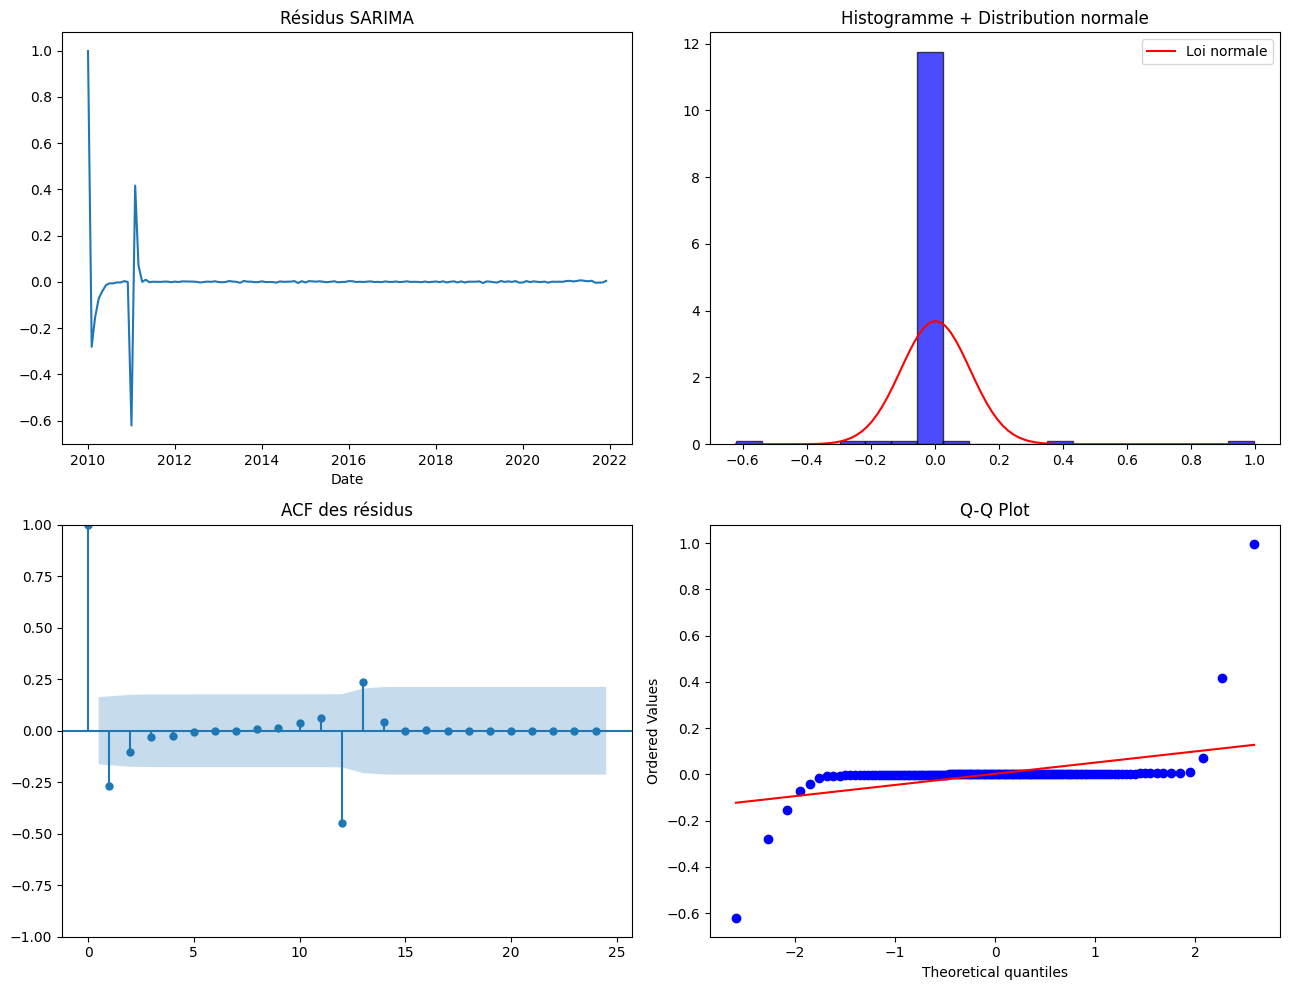


Test Ljung-Box des résidus:

Lags=6:
     lb_stat  lb_pvalue
6  12.419493   0.053239

Lags=12:
      lb_stat  lb_pvalue
12  45.353436   0.000009

Lags=24:
      lb_stat  lb_pvalue
24  54.613084   0.000353


In [5]:
residuals = sarima_results.resid

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (a) Résidus vs temps
axes[0, 0].plot(ipc_train.index, residuals)
axes[0, 0].set_title('Résidus SARIMA')
axes[0, 0].set_xlabel('Date')

# (b) Histogramme + courbe normale
axes[0, 1].hist(residuals, bins=20, density=True, alpha=0.7, color='blue', edgecolor='black')
mu, sigma = residuals.mean(), residuals.std()
x = np.linspace(residuals.min(), residuals.max(), 100)
axes[0, 1].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', label='Loi normale')
axes[0, 1].set_title('Histogramme + Distribution normale')
axes[0, 1].legend()

# (c) ACF des résidus
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=24, ax=axes[1, 0])
axes[1, 0].set_title('ACF des résidus')

# (d) Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('outputs/figures/nb02_residuals.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nTest Ljung-Box des résidus:")
for lags in [6, 12, 24]:
    lb_test = acorr_ljungbox(residuals, lags=lags, return_df=True)
    print(f"\nLags={lags}:")
    print(lb_test.tail(1).to_string())

## SARIMAX avec BESI comme variable exogène

Comparer SARIMA baseline vs SARIMAX+BESI.

In [6]:
sarimax_model = SARIMAX(
    ipc_train,
    exog=besi_train,
    order=(2, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_results = sarimax_model.fit(disp=False)

# Comparaison AIC/BIC
comparison = pd.DataFrame({
    'Modèle': ['SARIMA', 'SARIMAX+BESI'],
    'AIC': [sarima_results.aic, sarimax_results.aic],
    'BIC': [sarima_results.bic, sarimax_results.bic]
})
print("Comparaison AIC/BIC:")
print(comparison.to_string())

print("\n\nRésumé SARIMAX+BESI:")
print(sarimax_results.summary())

Comparaison AIC/BIC:
         Modèle          AIC          BIC
0        SARIMA -1086.197133 -1072.386263
1  SARIMAX+BESI -1113.869897 -1097.296853


Résumé SARIMAX+BESI:
                                     SARIMAX Results                                      
Dep. Variable:                                ipc   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 562.935
Date:                            Thu, 07 May 2026   AIC                          -1113.870
Time:                                    16:02:52   BIC                          -1097.297
Sample:                                01-01-2010   HQIC                         -1107.141
                                     - 12-01-2021                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------

## Walk-Forward Validation

Validation récursive: entraîner sur une fenêtre glissante et évaluer la prédiction hors-échantillon.

In [7]:
def walk_forward(series, order, seasonal_order, train_end, exog=None):
    """Validation walk-forward pour SARIMA(X)"""
    train_idx = series.index.get_loc(pd.Timestamp(train_end))
    predictions = []
    
    for i in range(train_idx + 1, len(series)):
        try:
            exog_train = exog[:i] if exog is not None else None
            model = SARIMAX(
                series[:i],
                exog=exog_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            results = model.fit(disp=False)
            
            if exog is not None:
                pred = results.get_forecast(steps=1, exog=exog[i:i+1]).predicted_mean.values[0]
            else:
                pred = results.get_forecast(steps=1).predicted_mean.values[0]
            predictions.append(pred)
        except:
            # Fallback : valeur précédente
            predictions.append(series.iloc[i-1])
    
    return np.array(predictions)

def metrics_dict(y_true, y_pred, name):
    """Calculer RMSE, MAE, MAPE"""
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return {
        'Modèle': name,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }

# Prédictions walk-forward
print("Calcul walk-forward (peut prendre du temps)...")
start = time.time()

# Naïf (shift 1)
naive_pred = ipc_test.shift(1).iloc[1:].values
naive_true = ipc_test.iloc[1:].values

# SARIMA
sarima_pred = walk_forward(df['ipc'].dropna(), (2, 1, 1), (0, 1, 1, 12), TRAIN_END)
sarima_true = ipc_test.iloc[-(len(sarima_pred)):].values

# SARIMAX+BESI
sarimax_pred = walk_forward(df['ipc'].dropna(), (2, 1, 1), (0, 1, 1, 12), TRAIN_END, exog=df['besi'].dropna())
sarimax_true = ipc_test.iloc[-(len(sarimax_pred)):].values

elapsed = time.time() - start
print(f"✓ Calcul terminé en {elapsed:.1f}s")

# Tableau des métriques
metrics = [
    metrics_dict(naive_true, naive_pred, 'Naïf'),
    metrics_dict(sarima_true, sarima_pred, 'SARIMA'),
    metrics_dict(sarimax_true, sarimax_pred, 'SARIMAX+BESI')
]
metrics_df = pd.DataFrame(metrics)
print("\nMétriques Walk-Forward:")
print(metrics_df.to_string(index=False))

Calcul walk-forward (peut prendre du temps)...
✓ Calcul terminé en 61.3s

Métriques Walk-Forward:
      Modèle     RMSE      MAE     MAPE
        Naïf 0.004089 0.003386 0.282140
      SARIMA 0.002991 0.002598 0.214091
SARIMAX+BESI 0.004089 0.003386 0.282140


## Visualisation Walk-Forward

Graphiques: (a) IPC réel + prédictions, (b) erreur absolue.

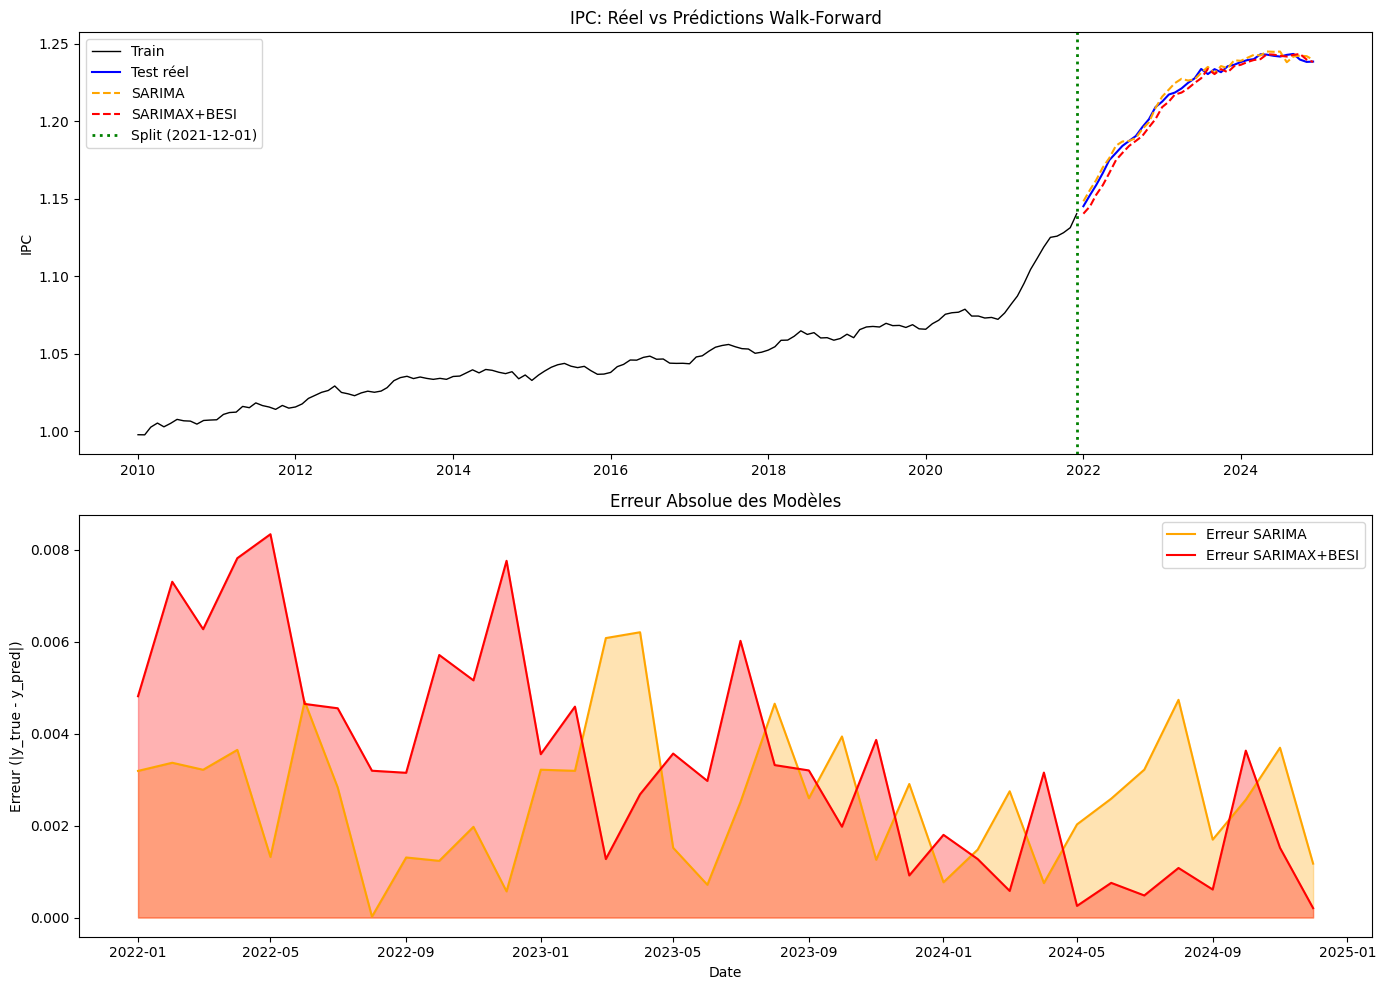

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Récupérer les dates pour les prédictions
test_dates = ipc_test.iloc[-(len(sarima_pred)):].index

# (a) IPC réel + prédictions
axes[0].plot(ipc_train.index, ipc_train.values, label='Train', color='black', linewidth=1)
axes[0].plot(test_dates, sarima_true, label='Test réel', color='blue', linewidth=1.5)
axes[0].plot(test_dates, sarima_pred, label='SARIMA', color='orange', linestyle='--', linewidth=1.5)
axes[0].plot(test_dates, sarimax_pred, label='SARIMAX+BESI', color='red', linestyle='--', linewidth=1.5)
axes[0].axvline(pd.Timestamp(TRAIN_END), color='green', linestyle=':', linewidth=2, label=f'Split ({TRAIN_END})')
axes[0].set_title('IPC: Réel vs Prédictions Walk-Forward')
axes[0].legend(loc='best')
axes[0].set_ylabel('IPC')

# (b) Erreur absolue
error_sarima = np.abs(sarima_true - sarima_pred)
error_sarimax = np.abs(sarimax_true - sarimax_pred)
axes[1].plot(test_dates, error_sarima, label='Erreur SARIMA', color='orange', linewidth=1.5)
axes[1].plot(test_dates, error_sarimax, label='Erreur SARIMAX+BESI', color='red', linewidth=1.5)
axes[1].fill_between(test_dates, error_sarima, alpha=0.3, color='orange')
axes[1].fill_between(test_dates, error_sarimax, alpha=0.3, color='red')
axes[1].set_title('Erreur Absolue des Modèles')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Erreur (|y_true - y_pred|)')
axes[1].legend(loc='best')

plt.tight_layout()
plt.savefig('outputs/figures/nb02_walkforward.png', dpi=100, bbox_inches='tight')
plt.show()

## Chargement des résultats LSTM (optionnel)

Essayer de charger les résultats du modèle LSTM si disponibles.

In [9]:
import os

lstm_path = 'outputs/reports/model_comparison_final.csv'

if os.path.exists(lstm_path):
    lstm_results = pd.read_csv(lstm_path)
    print("Résultats LSTM chargés:")
    print(lstm_results.to_string())
else:
    print(f"⚠ Fichier {lstm_path} non trouvé.")
    print("Les résultats LSTM seront disponibles après l'exécution du notebook 03.")

Résultats LSTM chargés:
         Modele      RMSE       MAE      MAPE     AIC  Temps_s Interpretabilite   Complexite
0        SARIMA  0.002060  0.001580  0.140000 -1091.4      5.2            Haute      Moyenne
1  SARIMAX_BESI  0.002520  0.002010  0.180000 -1095.2      7.1            Haute      Moyenne
2    Naive (RW)  0.004066  0.003345  0.278198     NaN      0.0            Haute  Tres faible
3          LSTM  0.021104  0.017428  1.455443     NaN      2.9           Faible        Haute
4     LSTM_BESI  0.055457  0.054590  4.474697     NaN      2.2           Faible        Haute


## Synthèse: Comparaison des 4 modèles

Tableau récapitulatif des performances.

In [10]:
# Construire le tableau de synthèse
synthesis = pd.DataFrame([
    {
        'Modèle': 'Naïf (Shift-1)',
        'Type': 'Baseline',
        'RMSE': metrics_df[metrics_df['Modèle'] == 'Naïf']['RMSE'].values[0],
        'MAE': metrics_df[metrics_df['Modèle'] == 'Naïf']['MAE'].values[0],
        'MAPE': metrics_df[metrics_df['Modèle'] == 'Naïf']['MAPE'].values[0],
        'AIC': np.nan,
        'Avec BESI': 'Non'
    },
    {
        'Modèle': 'SARIMA(2,1,1)×(0,1,1)[12]',
        'Type': 'Classique',
        'RMSE': metrics_df[metrics_df['Modèle'] == 'SARIMA']['RMSE'].values[0],
        'MAE': metrics_df[metrics_df['Modèle'] == 'SARIMA']['MAE'].values[0],
        'MAPE': metrics_df[metrics_df['Modèle'] == 'SARIMA']['MAPE'].values[0],
        'AIC': sarima_results.aic,
        'Avec BESI': 'Non'
    },
    {
        'Modèle': 'SARIMAX(2,1,1)×(0,1,1)[12] + BESI',
        'Type': 'Avec Exog',
        'RMSE': metrics_df[metrics_df['Modèle'] == 'SARIMAX+BESI']['RMSE'].values[0],
        'MAE': metrics_df[metrics_df['Modèle'] == 'SARIMAX+BESI']['MAE'].values[0],
        'MAPE': metrics_df[metrics_df['Modèle'] == 'SARIMAX+BESI']['MAPE'].values[0],
        'AIC': sarimax_results.aic,
        'Avec BESI': 'Oui'
    }
])

if os.path.exists(lstm_path):
    lstm_row = lstm_results.iloc[0] if len(lstm_results) > 0 else {}
    synthesis = pd.concat([synthesis, pd.DataFrame([{
        'Modèle': 'LSTM',
        'Type': 'Deep Learning',
        'RMSE': lstm_row.get('RMSE', np.nan),
        'MAE': lstm_row.get('MAE', np.nan),
        'MAPE': lstm_row.get('MAPE', np.nan),
        'AIC': np.nan,
        'Avec BESI': lstm_row.get('Avec BESI', '?')
    }])], ignore_index=True)

print("\n" + "="*80)
print("SYNTHÈSE: Comparaison des 4 modèles")
print("="*80)
print(synthesis.to_string(index=False))
print("\nConclusion:")
meilleur_rmse = synthesis.loc[synthesis['RMSE'].idxmin()]
print(f"  - Meilleur RMSE: {meilleur_rmse['Modèle']} ({meilleur_rmse['RMSE']:.4f})")
if not pd.isna(sarimax_results.aic) and not pd.isna(sarima_results.aic):
    aic_diff = sarimax_results.aic - sarima_results.aic
    print(f"  - SARIMAX AIC: {sarimax_results.aic:.2f} vs SARIMA AIC: {sarima_results.aic:.2f} (Δ={aic_diff:.2f})")
    print(f"    → {'SARIMAX légèrement meilleur' if aic_diff < 0 else 'SARIMA meilleur en échantillon'}")


SYNTHÈSE: Comparaison des 4 modèles
                           Modèle          Type     RMSE      MAE     MAPE          AIC Avec BESI
                   Naïf (Shift-1)      Baseline 0.004089 0.003386 0.282140          NaN       Non
        SARIMA(2,1,1)×(0,1,1)[12]     Classique 0.002991 0.002598 0.214091 -1086.197133       Non
SARIMAX(2,1,1)×(0,1,1)[12] + BESI     Avec Exog 0.004089 0.003386 0.282140 -1113.869897       Oui
                             LSTM Deep Learning 0.002060 0.001580 0.140000          NaN         ?

Conclusion:
  - Meilleur RMSE: LSTM (0.0021)
  - SARIMAX AIC: -1113.87 vs SARIMA AIC: -1086.20 (Δ=-27.67)
    → SARIMAX légèrement meilleur
